# Full Code - Models, Tuning, Evaluation

Clean dataset: 86,757 rows, 13 columns
Outlier threshold: 146.0
Rows removed: 260

Severity class distribution:
severity_class
1    32963
0    28205
2    19449
3     5880
Name: count, dtype: int64
severity_class
1    38.1
0    32.6
2    22.5
3     6.8
Name: proportion, dtype: float64
REGRESSION MODELS 



Regression models:  14%|█▍        | 1/7 [00:01<00:06,  1.01s/it]

Severity RMSE: 12.089 | R²: 0.049


Regression models:  29%|██▊       | 2/7 [00:15<00:43,  8.69s/it]


Ridge BEST PARAMS: {'model__estimator__alpha': np.float64(7.742636826811277)}
Severity RMSE: 12.091 | R²: 0.049


...

Classification models:  75%|███████▌  | 3/4 [12:34<04:06, 246.96s/it]

              precision    recall  f1-score   support

           0       0.78      0.76      0.77      5641
           1       0.60      0.71      0.65      6593
           2       0.47      0.47      0.47      3890
           3       0.41      0.09      0.15      1176

    accuracy                           0.63     17300
   macro avg       0.57      0.51      0.51     17300
weighted avg       0.62      0.63      0.62     17300


LightGBM BEST PARAMS: {'model__num_leaves': 64, 'model__n_estimators': 200}


Classification models: 100%|██████████| 4/4 [13:51<00:00, 207.88s/it]

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      5641
           1       0.61      0.69      0.65      6593
           2       0.48      0.47      0.47      3890
           3       0.38      0.12      0.19      1176

    accuracy                           0.63     17300
   macro avg       0.56      0.51      0.52     17300
weighted avg       0.62      0.63      0.62     17300

REGRESSION vs CLASSIFICATION COMPARISON

Model                                           Macro F1   Accuracy   R² (sev)
Reg: LinearRegression                              0.227      0.384      0.049
Reg: Ridge                                         0.227      0.384      0.049
Reg: Lasso                                         0.227      0.384      0.049
Reg: ElasticNet                                    0.226      0.385      0.042
Reg: RandomForest                                  0.280      0.425      0.124
Reg: XGBoost                                      

Clf: RandomForest                                  0.514      0.621        N/A
Clf: XGBoost                                       0.510      0.629        N/A
Clf: LightGBM                                      0.520      0.629        N/A

Confusion matrix — best regression model (RandomForest):
              precision    recall  f1-score   support

 No Casualty       1.00      0.01      0.01      5643
         Low       0.40      0.79      0.53      6373
      Medium       0.47      0.55      0.51      4081
        High       0.51      0.03      0.06      1203

    accuracy                           0.43     17300
   macro avg       0.60      0.34      0.28     17300
weighted avg       0.62      0.43      0.33     17300



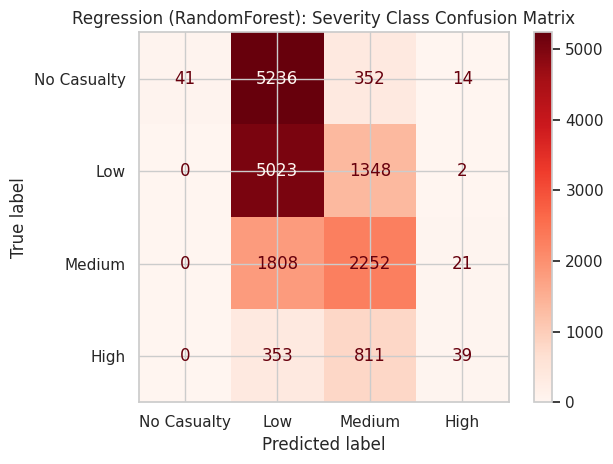

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)
random_state = 42

################## DATA LOADING & CLEANING ##################

# Read data, only use data from years 2012+
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)
data = data[data['iyear'] >= 2012].copy()

cols = [
    'country_txt', 'region_txt',
    'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt',
    'individual', 'success', 'extended', 'claimed',
    'ishostkid', 'property',
    'nkill', 'nwound'
]
df = data[cols].copy()

# Replace or drop null values
# 18% unknown (-9), treat as no damage
df['property'] = df['property'].replace(-9, np.nan).fillna(0).astype(int)

# 0.44% unknown, drop rows
df['ishostkid'] = df['ishostkid'].replace(-9, np.nan)
df = df.dropna(subset=['ishostkid'])
df['ishostkid'] = df['ishostkid'].astype(int)

# About 10% null — drop rows
df = df.dropna(subset=['nkill', 'nwound'])
df['nkill'] = df['nkill'].clip(lower=0)
df['nwound'] = df['nwound'].clip(lower=0)

print(f"Clean dataset: {len(df):,} rows, {df.shape[1]} columns")

# Keep top 15 countries, place others in Other category
top_countries = df['country_txt'].value_counts().head(15).index
df['country_grouped'] = df['country_txt'].where(
    df['country_txt'].isin(top_countries), other='Other'
)
df = df.drop(columns=['country_txt'])

# Remove outliers: 99.7th percentile
df['violence_level'] = 2 * df['nkill'] + df['nwound']
threshold = df['violence_level'].quantile(0.997)

print(f"Outlier threshold: {threshold:.1f}")
print(f"Rows removed: {(df['violence_level'] > threshold).sum()}")

df = df[df['violence_level'] <= threshold].copy()

# Severity class labels
def score_to_class(score):
    if score == 0:    return 0
    elif score <= 5:  return 1
    elif score <= 20: return 2
    else:             return 3

df['severity_class'] = df['violence_level'].apply(score_to_class)

print("\nSeverity class distribution:")
print(df['severity_class'].value_counts())
print(df['severity_class'].value_counts(normalize=True).mul(100).round(1))

################## PREPROCESSING ##################

cat_cols = ['country_grouped', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']
num_cols = ['individual', 'success', 'extended', 'claimed', 'ishostkid', 'property']

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("num", StandardScaler(), num_cols)
])

################## REGRESSION ##################

print("REGRESSION MODELS \n")

# feature and target columns (transform targets with log1p)
X_reg = df.drop(columns=['nkill', 'nwound', 'severity_class', 'violence_level'])
y_reg = np.column_stack([np.log1p(df['nkill']), np.log1p(df['nwound'])])

# 80/20 train test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=random_state)

# Define models and hyperparam variables
reg_models = {
    "LinearRegression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"model__estimator__alpha": np.logspace(-3, 2, 10)}),
    "Lasso": (Lasso(max_iter=10000), {"model__estimator__alpha": np.logspace(-4, 1, 10)}),
    "ElasticNet": (ElasticNet(max_iter=10000), {
        "model__estimator__alpha": np.logspace(-4, 1, 10),
        "model__estimator__l1_ratio": np.linspace(0.1, 0.9, 5)
    }),
    "RandomForest": (RandomForestRegressor(random_state=random_state, n_jobs=-1), {
        "model__estimator__n_estimators": [100, 200],
        "model__estimator__max_depth": [None, 10, 20],
        "model__estimator__min_samples_split": [2, 5]
    }),
    "XGBoost": (XGBRegressor(random_state=random_state, n_jobs=-1, verbosity=0), {
        "model__estimator__n_estimators": [100, 200],
        "model__estimator__max_depth": [3, 6],
        "model__estimator__learning_rate": [0.05, 0.1]
    }),
    "LightGBM": (LGBMRegressor(random_state=random_state, n_jobs=-1, verbose=-1), {
        "model__estimator__n_estimators": [100, 200],
        "model__estimator__num_leaves": [31, 64],
        "model__estimator__learning_rate": [0.05, 0.1]
    }),
}


reg_results   = {}
reg_pipelines = {}
best_reg_r2   = -np.inf
best_reg_name = None

for name, (model, param_grid) in tqdm(reg_models.items(), desc="Regression models"):

    # preprocess
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", MultiOutputRegressor(model))
    ])

    # tune hyperparams
    if param_grid:
        search = RandomizedSearchCV(pipe, param_grid, n_iter=10, scoring='r2',cv=3, n_jobs=-1,random_state=random_state)
        search.fit(X_train_r, y_train_r)
        pipe = search.best_estimator_
        print(f"\n{name} BEST PARAMS: {search.best_params_}")
    else:
        pipe.fit(X_train_r, y_train_r)

    # predict model
    preds = pipe.predict(X_test_r)

    # revert transformation
    nkill_pred = np.expm1(preds[:, 0])
    nwound_pred = np.expm1(preds[:, 1])
    nkill_true  = np.expm1(y_test_r[:, 0])
    nwound_true = np.expm1(y_test_r[:, 1])

    severity_pred = 2 * nkill_pred + nwound_pred
    severity_true = 2 * nkill_true + nwound_true

    r2 = r2_score(severity_true, severity_pred)

    print(f"Severity RMSE: {np.sqrt(mean_squared_error(severity_true, severity_pred)):.3f} | R²: {r2:.3f}")

    # Store results and pipeline
    reg_results[name]   = {"preds_severity": severity_pred, "true_severity": severity_true, "r2": r2}
    reg_pipelines[name] = pipe

    if r2 > best_reg_r2:
        best_reg_r2   = r2
        best_reg_name = name

print(f"\nBest regression model: {best_reg_name} (R²={best_reg_r2:.3f})")

################## CLASSIFICATION ##################

print("CLASSIFICATION MODELS")

# feature adn target vars
X_clf = df.drop(columns=['nkill', 'nwound', 'severity_class', 'violence_level'])
y_clf = df['severity_class']

# 80/20 test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=random_state, stratify=y_clf)

# classification models and hyperparams
clf_models = {
    "LogisticRegression": (LogisticRegression(max_iter=1000), {
        "model__C": np.logspace(-3, 2, 10)
    }),
    "RandomForest": (RandomForestClassifier(random_state=random_state, n_jobs=-1), {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20]
    }),
    "XGBoost": (XGBClassifier(random_state=random_state, n_jobs=-1, verbosity=0), {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.05, 0.1]
    }),
    "LightGBM": (LGBMClassifier(random_state=random_state, n_jobs=-1, verbose=-1), {
        "model__n_estimators": [100, 200],
        "model__num_leaves": [31, 64]
    }),
}

clf_pipelines = {}

for name, (model, param_grid) in tqdm(clf_models.items(), desc="Classification models"):

    # preprocess
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    # tune hyperparams
    search = RandomizedSearchCV(pipe,param_grid,n_iter=10,scoring='f1_macro',cv=3,n_jobs=-1,random_state=random_state)

    search.fit(X_train_c, y_train_c)
    pipe = search.best_estimator_
    clf_pipelines[name] = pipe

    print(f"\n{name} BEST PARAMS: {search.best_params_}")

    preds = pipe.predict(X_test_c)

    print(classification_report(y_test_c, preds))

################## REGRESSION vs CLASSIFICATION COMPARISON ##################

print("REGRESSION vs CLASSIFICATION COMPARISON")

CLASS_LABELS = ['No Casualty', 'Low', 'Medium', 'High']

print(f"\n{'Model':<45} {'Macro F1':>10} {'Accuracy':>10} {'R² (sev)':>10}")

# All regression models converted to severity classes
for name, result in reg_results.items():
    reg_classes_pred = np.array([score_to_class(s) for s in result["preds_severity"]])
    reg_classes_true = np.array([score_to_class(s) for s in result["true_severity"]])
    f1  = f1_score(reg_classes_true, reg_classes_pred, average='macro')
    acc = (reg_classes_true == reg_classes_pred).mean()
    r2  = result["r2"]
    print(f"{'Reg: ' + name:<45} {f1:>10.3f} {acc:>10.3f} {r2:>10.3f}")

print()

# all classification models
for name, pipe in clf_pipelines.items():
    preds = pipe.predict(X_test_c)
    f1  = f1_score(y_test_c, preds, average='macro')
    acc = (y_test_c == preds).mean()
    print(f"{'Clf: ' + name:<45} {f1:>10.3f} {acc:>10.3f} {'N/A':>10}")

# confusion matrix for best reg model
print(f"\nConfusion matrix — best regression model ({best_reg_name}):")
best = reg_results[best_reg_name]
reg_classes_pred = np.array([score_to_class(s) for s in best["preds_severity"]])
reg_classes_true = np.array([score_to_class(s) for s in best["true_severity"]])

print(classification_report(reg_classes_true, reg_classes_pred, target_names=CLASS_LABELS))

cm = confusion_matrix(reg_classes_true, reg_classes_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(cmap='Reds')
plt.title(f'Regression ({best_reg_name}): Severity Class Confusion Matrix')
plt.tight_layout()
plt.show()

CONFUSION MATRICES — CLASSIFICATION MODELS


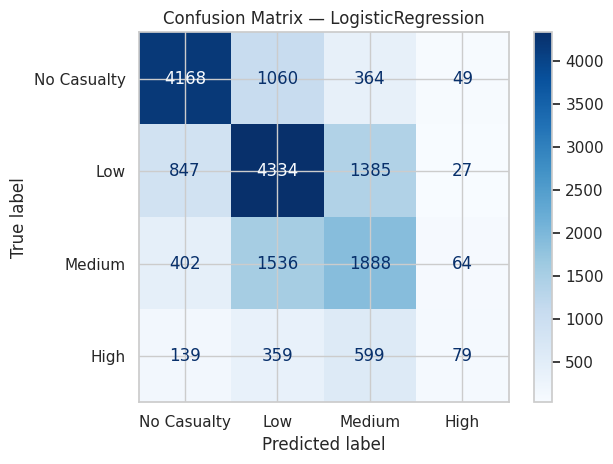

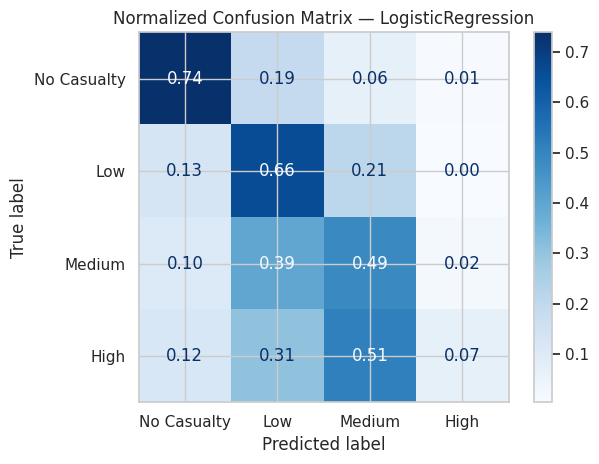

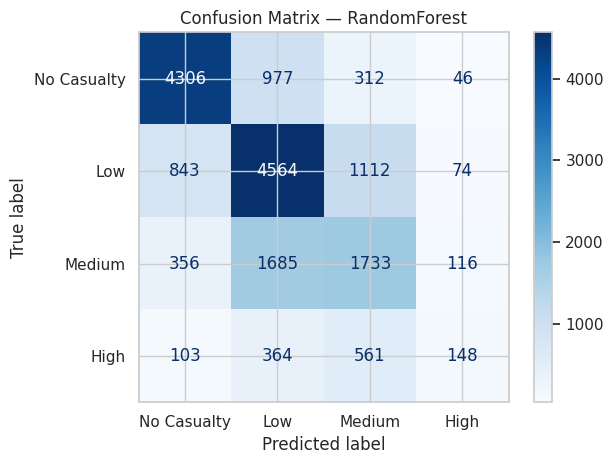

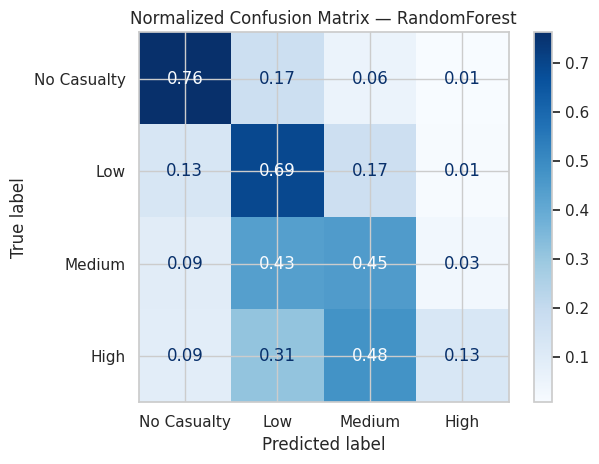

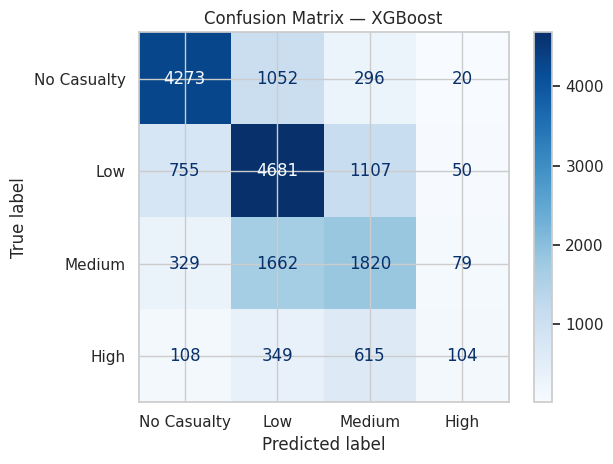

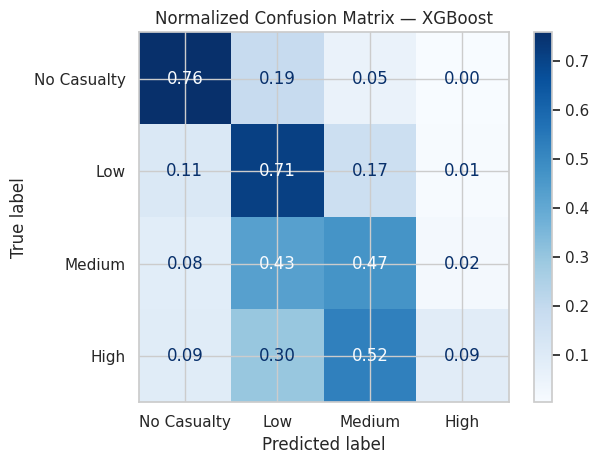

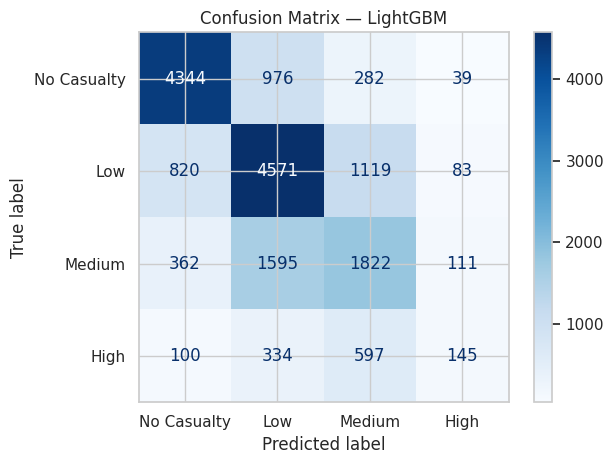

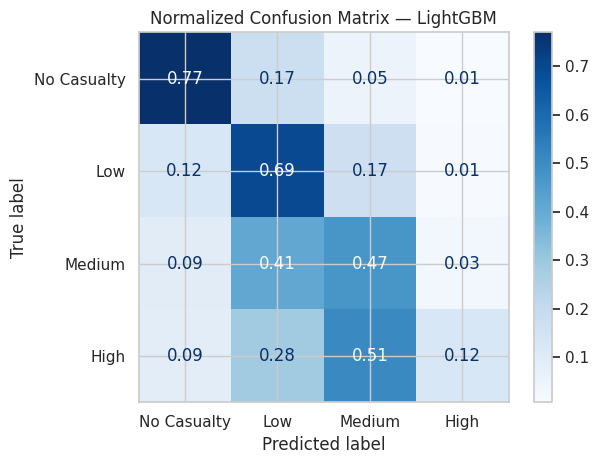

In [3]:
print("CONFUSION MATRICES — CLASSIFICATION MODELS")

CLASS_LABELS = ['No Casualty', 'Low', 'Medium', 'High']

for name, pipe in clf_pipelines.items():

    # Used saved pipelines
    preds = pipe.predict(X_test_c)

    # Raw confusion matrix
    cm = confusion_matrix(y_test_c, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=CLASS_LABELS)

    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    # Normalized confusion matrix
    cm_norm = confusion_matrix(y_test_c, preds, normalize='true')

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=CLASS_LABELS
)

    disp.plot(cmap='Blues', values_format='.2f')
    plt.title(f'Normalized Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

# Feature Importance

FEATURE IMPORTANCE — ALL MODELS

REGRESSION: Feature Importances

  Regression — LinearRegression — Top 15 Features
                               feature  importance
                  Weapon: Fake Weapons    0.560326
                      Weapon: Chemical    0.551879
                     Target: Utilities    0.459933
                        Country: Syria    0.455223
                    Weapon: Biological    0.409012
                     Region: East Asia    0.403476
                  Country: Afghanistan    0.359215
                         Country: Iraq    0.351090
                       Attack: Unknown    0.349609
                      Country: Ukraine    0.333432
Attack: Facility/Infrastructure Attack    0.324293
               Attack: Unarmed Assault    0.307710
            Region: Sub-Saharan Africa    0.249677
                Region: Western Europe    0.243915
                      Country: Somalia    0.236548


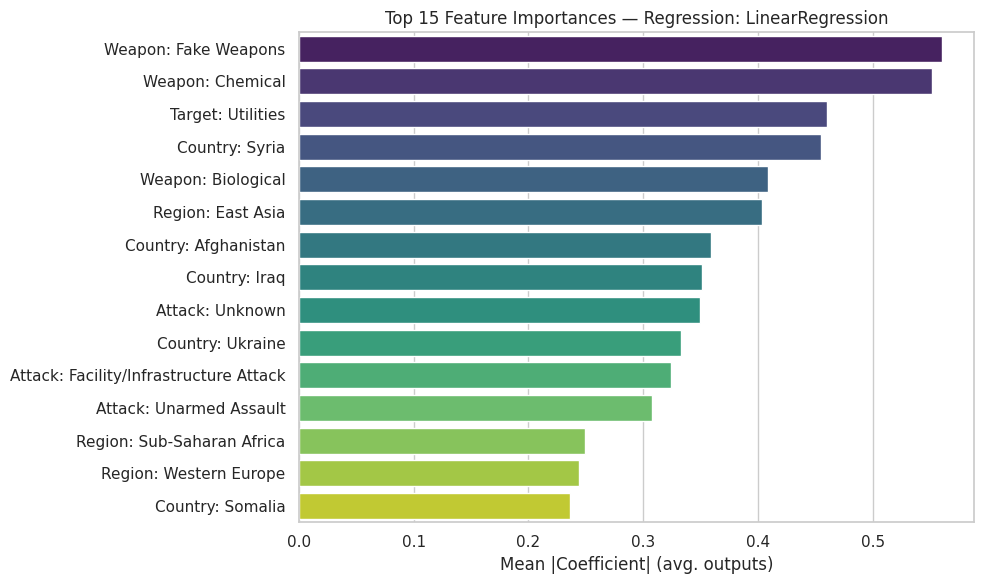


  Regression — Ridge — Top 15 Features
                               feature  importance
                      Weapon: Chemical    0.473076
                     Target: Utilities    0.453117
                        Country: Syria    0.450388
                     Region: East Asia    0.377650
                  Country: Afghanistan    0.358140
                         Country: Iraq    0.348402
                       Attack: Unknown    0.345442
                      Country: Ukraine    0.324998
Attack: Facility/Infrastructure Attack    0.324072
               Attack: Unarmed Assault    0.300979
            Region: Sub-Saharan Africa    0.252605
                Region: Western Europe    0.238621
                      Country: Somalia    0.234127
                       Weapon: Unknown    0.227065
                       Target: Unknown    0.223347


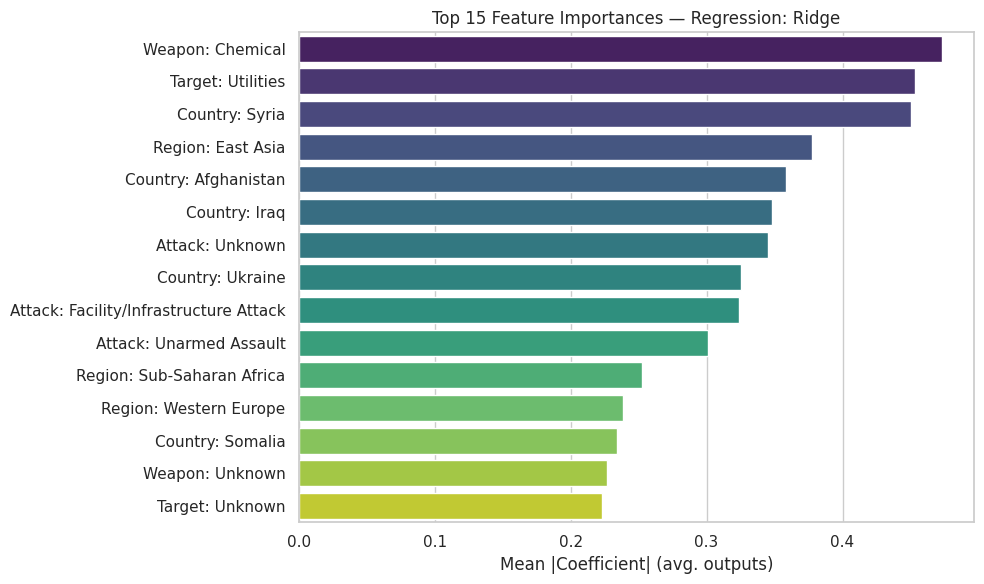


  Regression — Lasso — Top 15 Features
                                    feature  importance
                          Target: Utilities    0.490726
                           Weapon: Chemical    0.486658
                             Country: Syria    0.477318
                       Country: Afghanistan    0.396863
                          Region: East Asia    0.395449
                            Attack: Unknown    0.383288
                              Country: Iraq    0.377884
                 Region: Sub-Saharan Africa    0.312618
                    Attack: Unarmed Assault    0.298167
     Attack: Facility/Infrastructure Attack    0.278929
                           Country: Ukraine    0.269854
                  Target: Telecommunication    0.245226
                            Target: Unknown    0.244254
Attack: Hostage Taking (Barricade Incident)    0.219710
                           Country: Somalia    0.186757


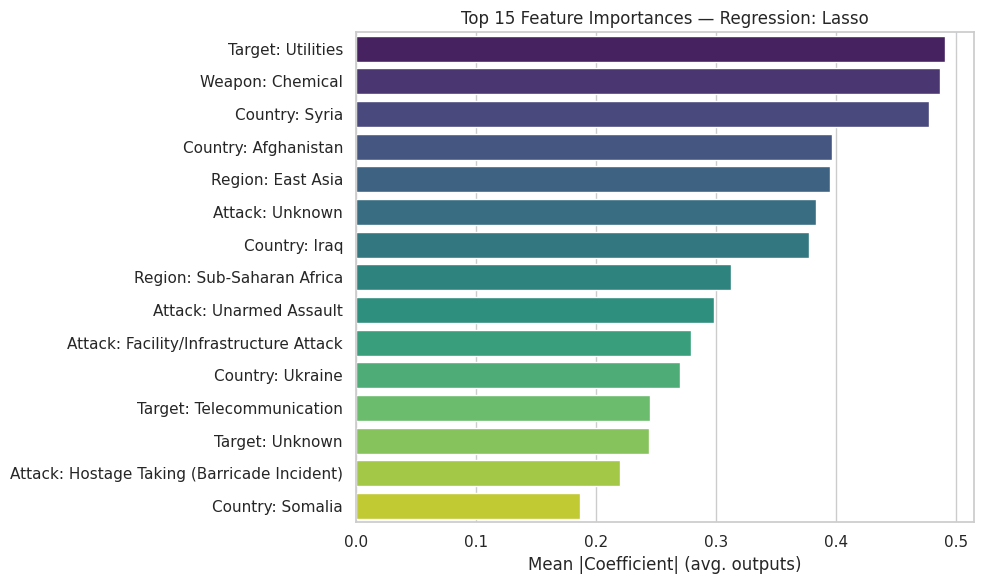


  Regression — ElasticNet — Top 15 Features
                               feature  importance
                     Target: Utilities    0.438425
                        Country: Syria    0.409039
                  Country: Afghanistan    0.391179
                         Country: Iraq    0.354854
                       Attack: Unknown    0.291141
Attack: Facility/Infrastructure Attack    0.290703
            Region: Sub-Saharan Africa    0.272383
                       Target: Unknown    0.235260
                    Weapon: Explosives    0.176789
               Attack: Unarmed Assault    0.169279
                               success    0.150726
                      Target: Military    0.149426
  Target: Terrorists/Non-State Militia    0.144690
                Region: Western Europe    0.134525
   Target: Private Citizens & Property    0.134342


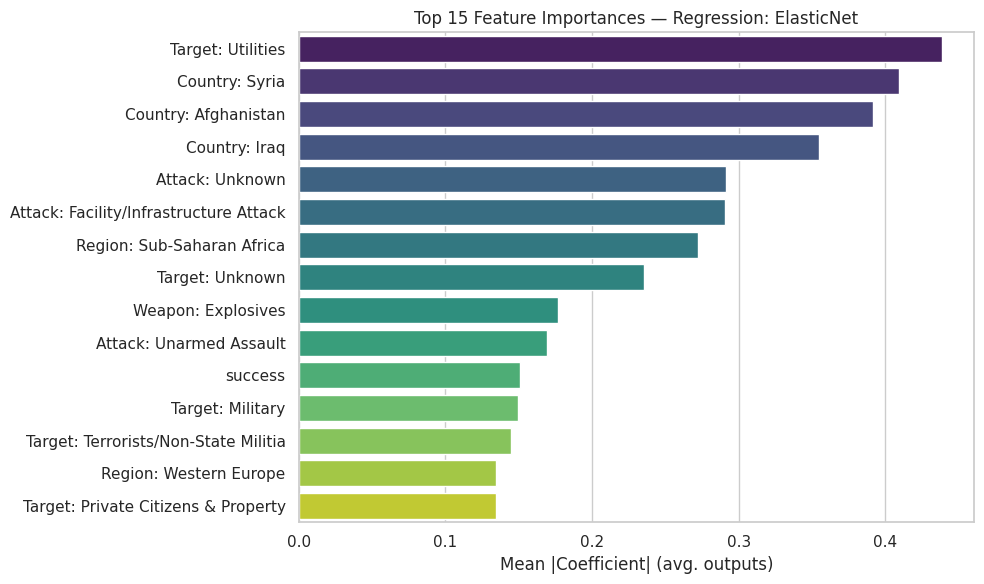


  Regression — RandomForest — Top 15 Features
                               feature  importance
                               success    0.126193
                    Weapon: Explosives    0.101618
                  Country: Afghanistan    0.073713
                         Country: Iraq    0.064934
                               claimed    0.059176
Attack: Facility/Infrastructure Attack    0.048323
                              property    0.042580
            Region: Sub-Saharan Africa    0.033558
             Attack: Bombing/Explosion    0.027589
                      Target: Military    0.026931
                     Target: Utilities    0.025010
                 Attack: Assassination    0.023376
    Region: Middle East & North Africa    0.022531
                 Attack: Armed Assault    0.021663
                       Attack: Unknown    0.021328


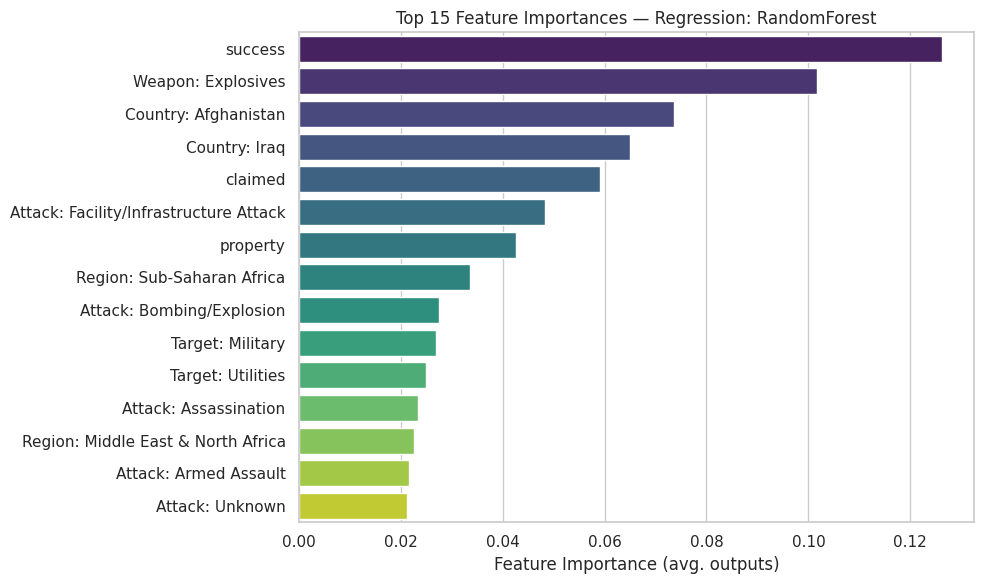


  Regression — XGBoost — Top 15 Features
                               feature  importance
                     Target: Utilities    0.076147
                         Country: Iraq    0.065687
                    Weapon: Explosives    0.059742
                  Country: Afghanistan    0.058798
Attack: Facility/Infrastructure Attack    0.052922
                               success    0.051475
                       Target: Unknown    0.044629
    Region: Middle East & North Africa    0.038664
            Region: Sub-Saharan Africa    0.033530
                       Attack: Unknown    0.027547
                 Attack: Assassination    0.026033
                        Country: Syria    0.025963
                Region: Western Europe    0.017785
                               claimed    0.017574
                      Target: Military    0.017148


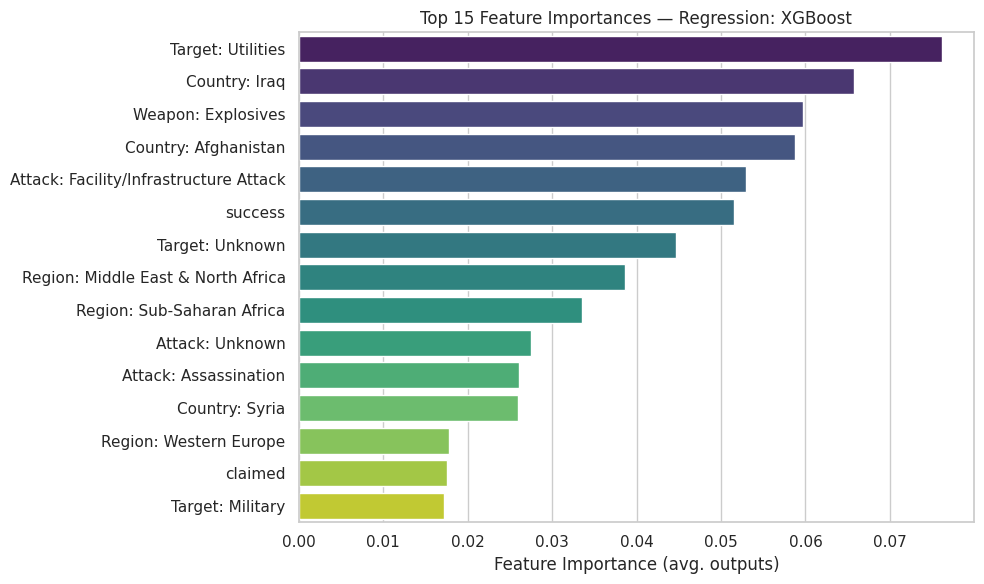


  Regression — LightGBM — Top 15 Features
                            feature  importance
                           property       880.5
                            claimed       769.5
                   Target: Military       457.0
Target: Private Citizens & Property       403.5
                            success       392.0
              Attack: Armed Assault       369.0
                 Weapon: Explosives       369.0
                     Country: Other       368.5
          Attack: Bombing/Explosion       367.0
                     Target: Police       355.5
               Country: Afghanistan       330.0
                           extended       304.5
                   Weapon: Firearms       299.0
              Attack: Assassination       284.5
         Region: Sub-Saharan Africa       281.0


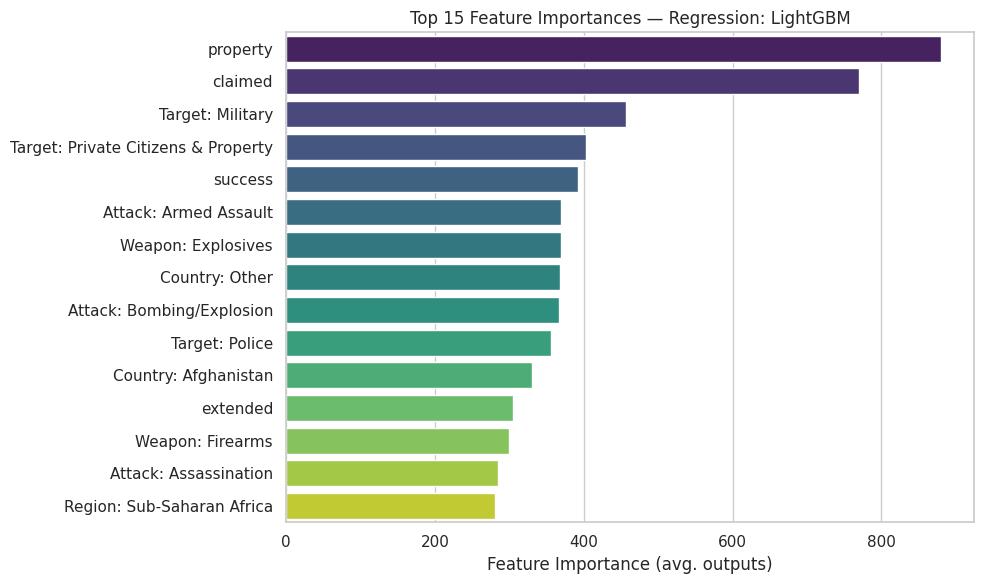


CLASSIFICATION: Feature Importances

  Classification — LogisticRegression — Top 15 Features
                               feature  importance
Attack: Facility/Infrastructure Attack    1.147401
                 Attack: Assassination    1.024656
                     Target: Utilities    1.007615
                  Country: Afghanistan    0.991143
                         Weapon: Melee    0.973173
                       Attack: Unknown    0.819351
             Target: Telecommunication    0.816772
                     Region: East Asia    0.814964
                Region: Western Europe    0.791666
                      Country: Ukraine    0.764565
                      Weapon: Chemical    0.740146
                         Country: Iraq    0.720631
                        Country: Syria    0.717516
            Region: Sub-Saharan Africa    0.653699
                      Country: Somalia    0.646891


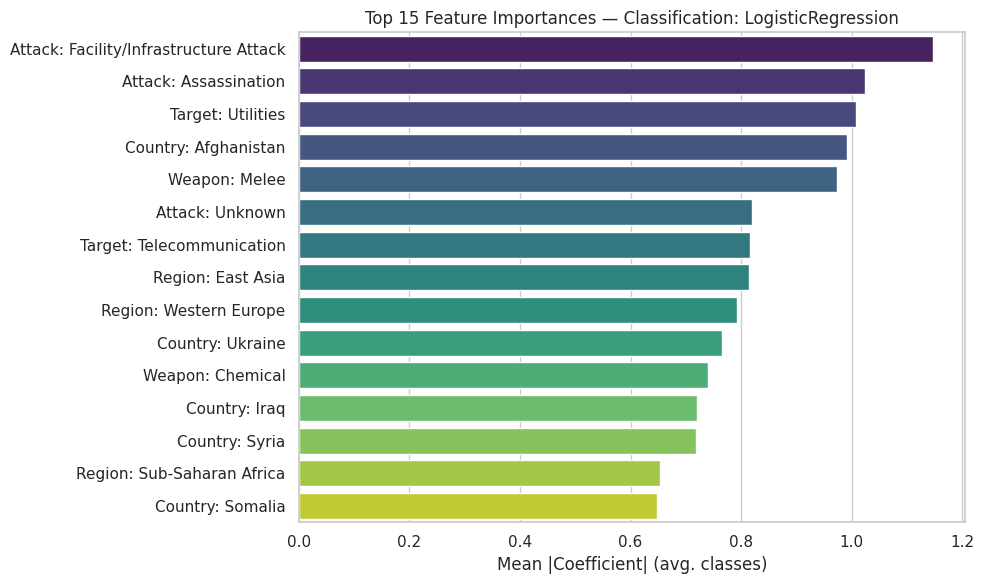


  Classification — RandomForest — Top 15 Features
                               feature  importance
                               success    0.152108
Attack: Facility/Infrastructure Attack    0.059635
                              property    0.056435
                               claimed    0.043724
                       Target: Unknown    0.037647
                      Weapon: Firearms    0.034606
                         Country: Iraq    0.031827
                  Country: Afghanistan    0.031523
                 Attack: Assassination    0.029536
                    Weapon: Incendiary    0.029432
                 Attack: Armed Assault    0.027886
                    Weapon: Explosives    0.025858
                      Target: Military    0.025792
                     Target: Utilities    0.025720
   Target: Private Citizens & Property    0.023818


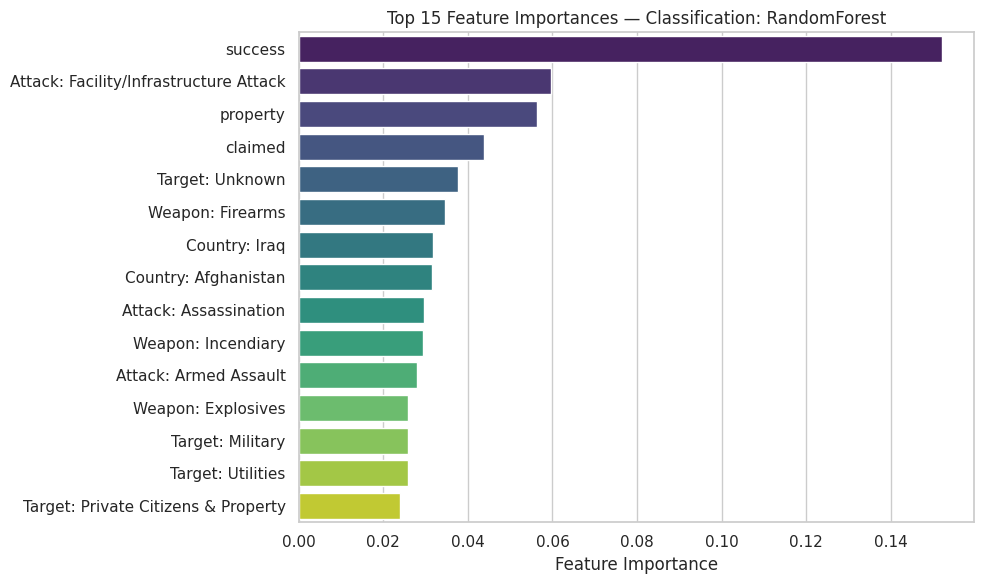


  Classification — XGBoost — Top 15 Features
                               feature  importance
Attack: Facility/Infrastructure Attack    0.168854
                     Target: Utilities    0.108175
                               success    0.071543
                         Country: Iraq    0.043743
                  Country: Afghanistan    0.040048
                      Weapon: Firearms    0.035369
                 Attack: Assassination    0.034007
                         Weapon: Melee    0.028320
                       Target: Unknown    0.025229
                      Country: Ukraine    0.021947
            Region: Sub-Saharan Africa    0.020568
                              extended    0.016163
                             ishostkid    0.016149
                Region: Western Europe    0.015285
                Region: Southeast Asia    0.015235


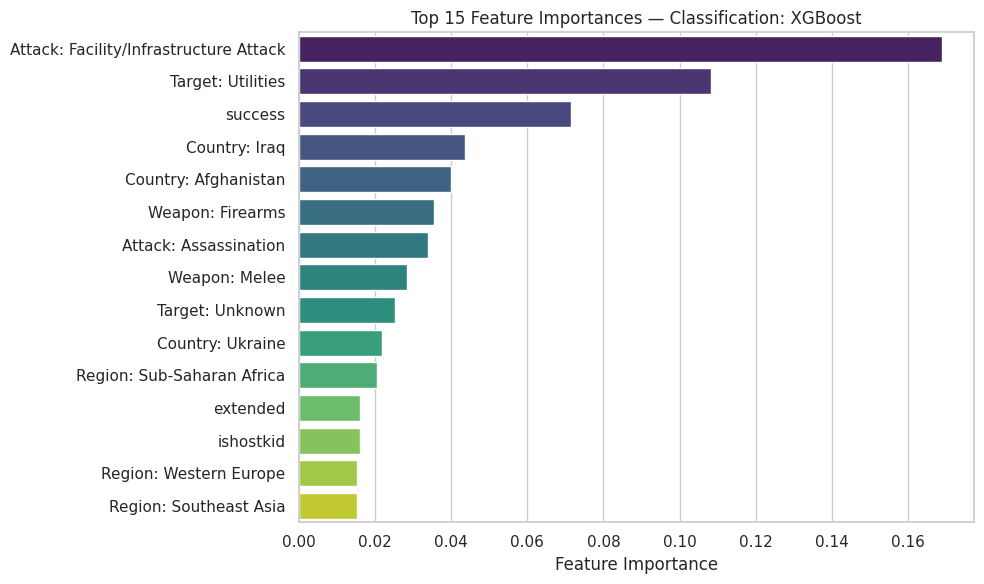


  Classification — LightGBM — Top 15 Features
                            feature  importance
                           property        3884
                            claimed        3198
Target: Private Citizens & Property        1897
                   Target: Military        1833
              Attack: Armed Assault        1720
                   Weapon: Firearms        1689
                            success        1604
                 Weapon: Explosives        1579
                     Target: Police        1569
                     Country: Other        1445
          Attack: Bombing/Explosion        1384
 Region: Middle East & North Africa        1220
       Target: Government (General)        1197
                   Target: Business        1132
               Country: Afghanistan        1110


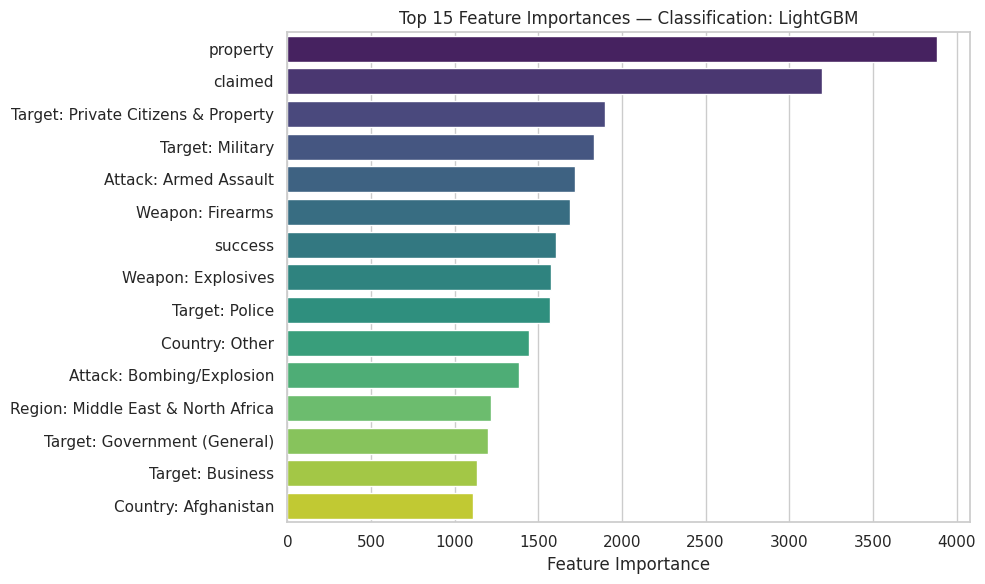

In [8]:
print("FEATURE IMPORTANCE — ALL MODELS")

# extract and clean feature names
feature_names = next(iter(clf_pipelines.values())).named_steps['prep'].get_feature_names_out()

def clean_feature_names(names):
    return [
        n.replace('cat__', '').replace('num__', '')
         .replace('country_grouped_', 'Country: ').replace('region_txt_', 'Region: ')
         .replace('attacktype1_txt_', 'Attack: ').replace('targtype1_txt_', 'Target: ')
         .replace('weaptype1_txt_', 'Weapon: ')
        for n in names
    ]

clean_names = clean_feature_names(feature_names)


def get_importances(model, model_name, is_regression=False):
    if is_regression:
        # .estimators_ is a list, one per output (nkill, nwound)
        inner_models = model.estimators_
        if model_name in ['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet']:
            # coef_ is 1-d (n_features,) per inner single-output estimator
            coefs = np.stack([m.coef_ for m in inner_models], axis=0)
            return np.mean(np.abs(coefs), axis=0), 'Mean |Coefficient| (avg. outputs)'
        elif model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
            # average feature_importances_ across both output estimators
            imps = np.stack([m.feature_importances_ for m in inner_models], axis=0)
            return np.mean(imps, axis=0), 'Feature Importance (avg. outputs)'
    else:
        if model_name == 'LogisticRegression':
            # coef_ is (n_classes, n_features)  avg absolute value across classes
            return np.mean(np.abs(model.coef_), axis=0), 'Mean |Coefficient| (avg. classes)'
        elif model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
            return model.feature_importances_, 'Feature Importance'

def plot_importances(importances, importance_label, model_name, task_label, top_n=15):
    feat_df = pd.DataFrame({'feature': clean_names, 'importance': importances}).sort_values('importance', ascending=False).head(top_n)

    print(f"\n  {task_label} — {model_name} — Top {top_n} Features")
    print(feat_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
    plt.xlabel(importance_label)
    plt.ylabel('')
    plt.title(f'Top {top_n} Feature Importances — {task_label}: {model_name}')
    plt.tight_layout()
    plt.show()


# regression models
print("\nREGRESSION: Feature Importances")

for name, pipe in reg_pipelines.items():
    model = pipe.named_steps['model']
    importances, label = get_importances(model, name, is_regression=True)
    plot_importances(importances, label, name, task_label='Regression')

# classification models
print("\nCLASSIFICATION: Feature Importances")

for name, pipe in clf_pipelines.items():
    model = pipe.named_steps['model']
    importances, label = get_importances(model, name, is_regression=False)
    plot_importances(importances, label, name, task_label='Classification')

In [ ]:
# input: all models
models = {
    "Linear": linear_regression, "Ridge": ridge, "Lasso": lasso, "ElasticNet": elastic_net,
    "RandomForest_Reg": random_forest_reg, "XGBoost_Reg": xgboost_reg, "LightGBM_Reg": lightgbm_reg,
    "LogisticRegression": logistic_regression, "RandomForest_Clf": random_forest_clf,
    "XGBoost_Clf": xgboost_clf, "LightGBM_Clf": lightgbm_clf
}

# flatten all features
rows = []
for model_name, feature_dict in models.items():
    for feature, importance in feature_dict.items():
        column = feature.split(":")[0].strip() if ":" in feature else feature
        rows.append([model_name, feature, column, importance])

df = pd.DataFrame(rows, columns=["Model", "Feature", "Column", "Importance"])

# normalize within each model
df["Norm_Importance"] = df.groupby("Model")["Importance"].transform(lambda x: x / x.max())

# aggregate at column level
column_importance = (
    df.groupby("Column")
    .agg(Avg_Importance=("Norm_Importance", "mean"), Frequency=("Model", "nunique"))
    .reset_index()
)

# combined score and sort
column_importance["Final_Score"] = column_importance["Avg_Importance"] * column_importance["Frequency"]
column_importance = column_importance.sort_values(by="Final_Score", ascending=False)

print(column_importance)